In [1]:
import avalanche as av
import networkx as nx
import numpy as np
import random
import time
import gudhi
import matplotlib.pyplot as plt

### First create the adjacency matrix of a graph, either directly or via networkx

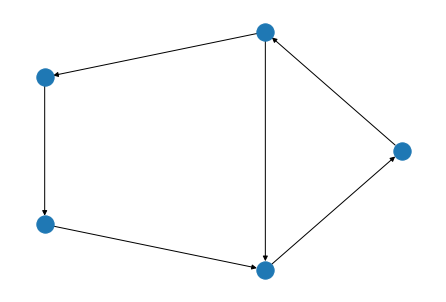

In [193]:
# Create the "house" graph 
G = nx.DiGraph()
G.add_edges_from([(0,1),(1,2),(2,3),(3,4),(4,0),(1,4)])

# Create a list of vertices to connect to the sink,
# or leave the list empty if there is no sink
sinks = []

# Get the adjacency matrix
G_M = nx.adjacency_matrix(G).todense()

# Draw the graph
nx.draw(G,nx.circular_layout(G))

## Next specify a configuration and compute the avalanche complex

In [209]:
# Specify an initial configuration of the sandpile
c = [2,0,0,0,1]

# Compute the avalanche complex
av_G = av.avalanche_complex(G_M,c,sinks=sinks)

# print the Betti numbers
bettis = av_G.betti_numbers()
print(bettis)

[1, 1, 0, 0]


### If we want to see the toppling sets of the sandpile, we can enable print_firings

In [210]:
# Compute the avalanche complex
av_G = av.avalanche_complex(G_M,c,sinks=sinks, print_firings=True)

t = 0  :  [0, 4]
t = 1  :  [0]
t = 2  :  [0, 1]
t = 3  :  [2, 4]
t = 4  :  [0, 3]
t = 5  :  [1, 4]
t = 6  :  [0, 2, 4]


### To get the persistent homology we enable persistence

In [212]:
# Compute the filtered avalanche complex
av_G = av.avalanche_complex(G_M,c,sinks=sinks, persistence=True)

# print the persistent_pairs
persistent_pairs = av_G.persistence(persistence_dim_max=True)
print(persistent_pairs)

[(1, (5.0, inf)), (0, (0.0, inf))]


#### Note it is IMPORTANT to set persistence_dim_max=True when calling persistence(), as otherwise the top dimensional homology may not be computed

### Plot the persistence diagram

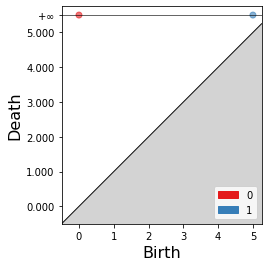

In [213]:
av.avalanche_complex_persistence_diagram(av_G)

### A second Example on the same graph, with a different initial configuration, this time with a sink

t = 0  :  [0]
t = 1  :  [0]
t = 2  :  [1]
t = 3  :  [2, 4]
t = 4  :  [0, 3]
Betti Numbers : [3, 0]
Persistent Pairs : [(0, (0.0, inf)), (0, (2.0, inf)), (0, (3.0, inf))]


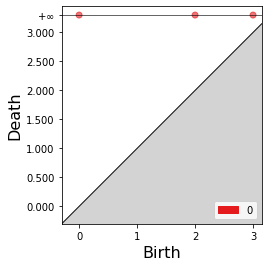

In [221]:
G = nx.DiGraph()                                                                         #Create Empty graph
G.add_edges_from([(0,1),(1,2),(2,3),(3,4),(4,0),(1,4)])                                  #Add edges
sinks = [4]                                                                              #Specify sinks
G_M = nx.adjacency_matrix(G).todense()                                                   #Get adjacency matrix
c2 = [1,0,2,0,1]                                                                         #Specify configuration
av_G2 = av.avalanche_complex(G_M,c,sinks=sinks, persistence=True, print_firings=True)    #Compute avalanche complex
print("Betti Numbers :", av_G2.betti_numbers())                                          #Print Betti numbers
print("Persistent Pairs :", av_G2.persistence(persistence_dim_max=True))                 #Print persistent pairs
av.avalanche_complex_persistence_diagram(av_G2)                                          #Plot persistent diagram

## The sandpile model will run until either 1) it stabilises, 2) it becomes recurrent, or 3) the firings exceeds the specified length, which by default is 1000

### Consider the path of length 50, with 2 grains on the first vertex, if we set firings=20, then the simulation will run for 20 steps and then terminate, thus the output is NOT the actual avalanche complex

In [230]:
long_P = nx.DiGraph()                                                                       
long_P.add_edges_from([(i,i+1) for i in range(49)])   
sinks = [49]                                                                             
long_P_M = nx.adjacency_matrix(long_P).todense()                                           
c3 = [2]+[0]*49                                                                         
av_P = av.avalanche_complex(long_P_M,c3,sinks=sinks, persistence=True, print_firings=True, firings=20)        

t = 0  :  [0]
t = 1  :  [0, 1]
t = 2  :  [1, 2]
t = 3  :  [2, 3]
t = 4  :  [3, 4]
t = 5  :  [4, 5]
t = 6  :  [5, 6]
t = 7  :  [6, 7]
t = 8  :  [7, 8]
t = 9  :  [8, 9]
t = 10  :  [9, 10]
t = 11  :  [10, 11]
t = 12  :  [11, 12]
t = 13  :  [12, 13]
t = 14  :  [13, 14]
t = 15  :  [14, 15]
t = 16  :  [15, 16]
t = 17  :  [16, 17]
t = 18  :  [17, 18]
t = 19  :  [18, 19]
t = 20  :  [19, 20]
t = 21  :  [20, 21]
